In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load the dataset
df = pd.read_csv('heart999.csv')

In [3]:
# Initial impression of data
print(df.head())
print(df.info())
print(df.describe())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

In [4]:
#replace 0 with NaN
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

In [ ]:
#data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     746 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [6]:
#Filling NaN values with median based on gender of the patient
df['RestingBP'] = df.groupby('Sex')['RestingBP'].transform(lambda x: x.fillna(x.median()))
df['Cholesterol'] = df.groupby('Sex')['Cholesterol'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [8]:
# select categorical columns
#categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
#categorical_cols = list(set(categorical_cols + ['FastingBS']))
#print(categorical_cols)
# select categorical columns
categorical_cols = ['RestingECG', 'ChestPainType', 'ExerciseAngina', 'FastingBS', 'ST_Slope', 'Sex']
print(categorical_cols)

['RestingECG', 'ChestPainType', 'ExerciseAngina', 'FastingBS', 'ST_Slope', 'Sex']


In [9]:
#Identifying numerical columns
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(numerical_cols)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [10]:
TARGET = 'HeartDisease'

In [11]:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

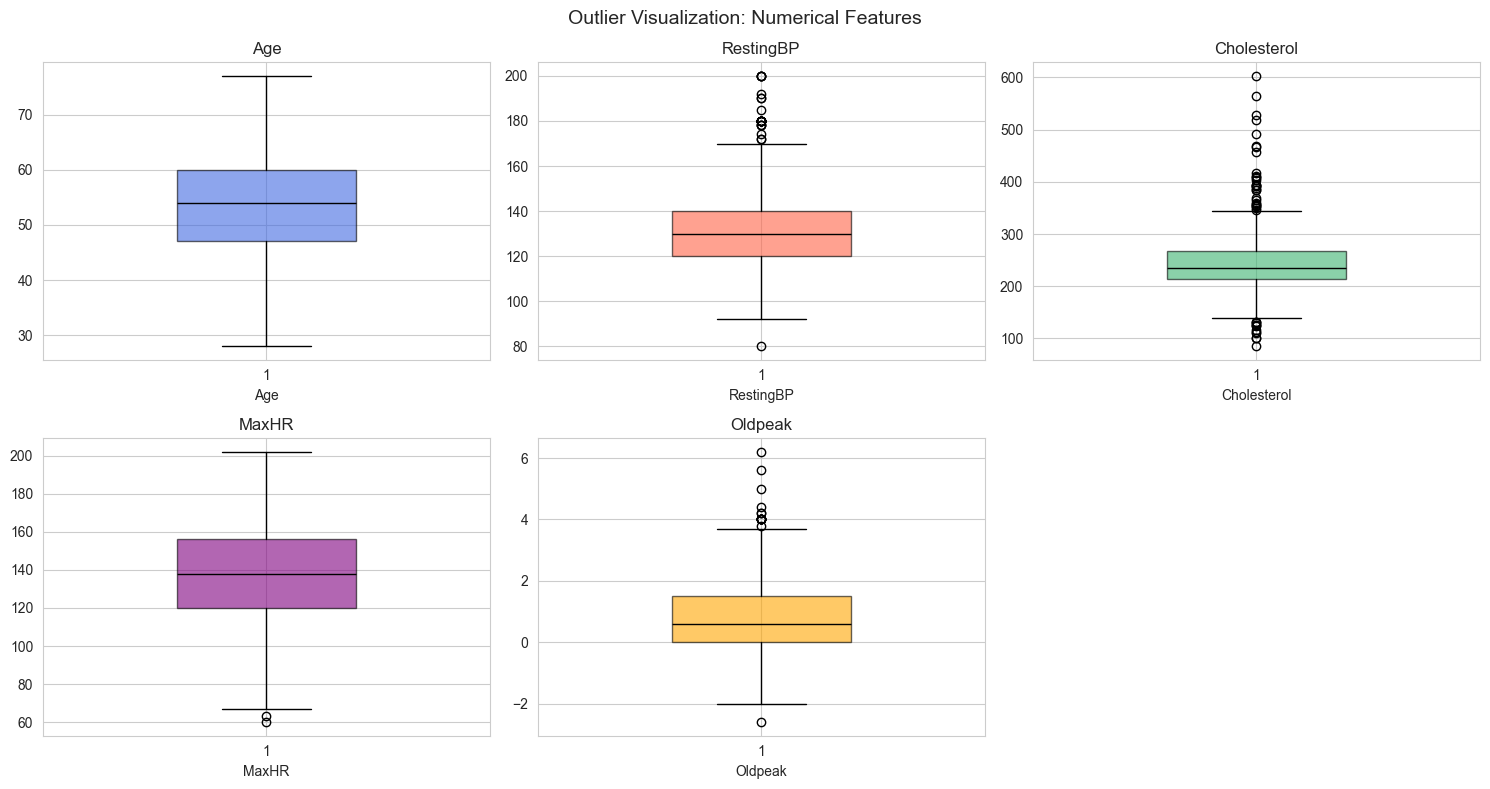

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style (to match your image look)
sns.set_style("whitegrid")

colors = ["royalblue", "tomato", "mediumseagreen", "purple", "orange", "teal"]

# Dynamic layout (3 per row like your example)
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        widths=0.4,
        boxprops=dict(facecolor=colors[i], alpha=0.6),
        medianprops=dict(color="black"),
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
plt.suptitle("Outlier Visualization: Numerical Features", fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
#IQR Method for Outlier Detection


Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Boolean mask for outliers
iqr_outliers = (df[numerical_cols] < (Q1 - 1.5 * IQR)) | \
               (df[numerical_cols] > (Q3 + 1.5 * IQR))

# Count outliers per feature
iqr_outlier_count = iqr_outliers.sum()

print(iqr_outlier_count)


Age             0
RestingBP      27
Cholesterol    41
MaxHR           2
Oldpeak        16
dtype: int64


In [14]:
df_iqr = df.copy()

Q1 = df_iqr[numerical_cols].quantile(0.25)
Q3 = df_iqr[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_flags = (
    (df_iqr[numerical_cols] < (Q1 - 1.5 * IQR)) |
    (df_iqr[numerical_cols] > (Q3 + 1.5 * IQR))
)

# Per-feature flags
for col in numerical_cols:
    df_iqr[f"{col}_IQR_flag"] = iqr_flags[col].astype(int)

# Any IQR outlier indicator
df_iqr["IQR_Any_Outlier"] = iqr_flags.any(axis=1).astype(int)
df_iqr.filter(like="_IQR_flag").sum().sort_values(ascending=False)


Cholesterol_IQR_flag    41
RestingBP_IQR_flag      27
Oldpeak_IQR_flag        16
MaxHR_IQR_flag           2
Age_IQR_flag             0
dtype: int64

In [15]:
#isolation Forest -  for Outlier Detection
from sklearn.ensemble import IsolationForest
iso_features = df_iqr[numerical_cols]

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # conservative for medical data
    random_state=42
)

df_iqr["IsolationForest_Score"] = iso_model.fit_predict(iso_features)

# Convert to binary flag: 1 = outlier
df_iqr["IsolationForest_Outlier"] = (
    df_iqr["IsolationForest_Score"] == -1
).astype(int)
df_iqr["IsolationForest_Outlier"].value_counts()


IsolationForest_Outlier
0    872
1     46
Name: count, dtype: int64

In [16]:
#Winsorization — Cap Extremes (NO ROW DELETION)
df_winsor = df_iqr.copy()

for col in numerical_cols:
    lower = df_winsor[col].quantile(0.01)
    upper = df_winsor[col].quantile(0.99)

    df_winsor[col] = df_winsor[col].clip(lower=lower, upper=upper)

# Combined Anomaly Profile
df_winsor["Any_Outlier"] = (
    (df_winsor["IQR_Any_Outlier"] == 1) |
    (df_winsor["IsolationForest_Outlier"] == 1)
).astype(int)

df_model = df_winsor.copy()
df_model


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,HeartDisease,Age_IQR_flag,RestingBP_IQR_flag,Cholesterol_IQR_flag,MaxHR_IQR_flag,Oldpeak_IQR_flag,IQR_Any_Outlier,IsolationForest_Score,IsolationForest_Outlier,Any_Outlier
0,40,1,1,140.0,289.0,0,1,172.0,0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,49,0,2,160.0,180.0,0,1,156.0,0,1.0,...,1,0,0,0,0,0,0,1,0,0
2,37,1,1,130.0,283.0,0,2,98.0,0,0.0,...,0,0,0,0,0,0,0,1,0,0
3,48,0,0,138.0,214.0,0,1,108.0,1,1.5,...,1,0,0,0,0,0,0,1,0,0
4,54,1,2,150.0,195.0,0,1,122.0,0,0.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110.0,264.0,0,1,132.0,0,1.2,...,1,0,0,0,0,0,0,1,0,0
914,68,1,0,144.0,193.0,1,1,141.0,0,3.4,...,1,0,0,0,0,0,0,1,0,0
915,57,1,0,130.0,131.0,0,1,115.0,1,1.2,...,1,0,0,1,0,0,1,1,0,1
916,57,0,1,130.0,236.0,0,0,174.0,0,0.0,...,1,0,0,0,0,0,0,1,0,0


In [17]:
#Shapiro wilk test for normality
from scipy.stats import shapiro

print(f"{'Feature':<15} | {'P-Value':<25} | {'Result'}")
print("-" * 55)

for col in numerical_cols:
    start, p_value = shapiro(df[col])

    result = "Not Normal" if p_value < 0.05 else "Normal"
    print(f"{col:<15} | {p_value:<25} | {result}")

Feature         | P-Value                   | Result
-------------------------------------------------------
Age             | 2.1651677122144785e-05    | Not Normal
RestingBP       | 1.6866481975976585e-12    | Not Normal
Cholesterol     | 2.8774916320511545e-23    | Not Normal
MaxHR           | 0.00016833523180415343    | Not Normal
Oldpeak         | 8.271839084051427e-28     | Not Normal


In [18]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[numerical_cols] = pt.fit_transform(df[numerical_cols])
print(df[numerical_cols].head())

        Age  RestingBP  Cholesterol     MaxHR   Oldpeak
0 -1.408156   0.495355     0.927753  1.407658 -0.851394
1 -0.507876   1.454389    -1.302398  0.748173  0.286444
2 -1.693030  -0.055605     0.827733 -1.500984 -0.851394
3 -0.611116   0.389441    -0.494023 -1.131070  0.709738
4  0.019655   0.996202    -0.929371 -0.599786 -0.851394


In [19]:
#Splitting between testing and training data
target = 'HeartDisease'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 734 samples
Testing set size: 184 samples


In [20]:
#Imports
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)



#Unified Evaluation Function
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }

# Define Candidate Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42
    )
}

#Train & Compare Models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")
results_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.836957,0.846154,0.862745,0.854369
Random Forest,0.875000,0.883495,0.892157,0.887805
KNN,0.842391,0.892473,0.813725,0.851282
SVM (RBF),0.842391,0.868687,0.843137,0.855721
Decision Tree,0.809783,0.825243,0.833333,0.829268


In [ ]:
#Gender Specific model comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, random_state=42)
}


#Gender-Wise Evaluation Function
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)
import pandas as pd

def gender_wise_metrics(model, X_test, y_test, gender_col="gender", threshold=0.5):
    rows = []

    for gender_value, gender_label in [(0, "Female"), (1, "Male")]:
        idx = X_test[gender_col] == gender_value

        X_g = X_test.loc[idx]
        y_g = y_test.loc[idx]

        y_prob = model.predict_proba(X_g)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        #y_pred = model.predict(X_g)

        rows.append({
            "Gender": gender_label,
            "Samples": len(y_g),
            "Accuracy": accuracy_score(y_g, y_pred),
            "Precision": precision_score(y_g, y_pred, zero_division=0),
            "Recall": recall_score(y_g, y_pred),
            "F1-score": f1_score(y_g, y_pred),
        })

    return pd.DataFrame(rows)

#Train All Models & Collect Gender-Wise Results
all_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    gender_df = gender_wise_metrics(
        model=model,
        X_test=X_test,
        y_test=y_test,
        gender_col="Sex"
    )

    gender_df["Model"] = model_name
    all_results.append(gender_df)

gender_results = pd.concat(all_results, ignore_index=True)
gender_results


,Gender,Samples,Accuracy,Precision,Recall,F1-score,Model
0,Female,38,0.868421,0.571429,0.666667,0.615385,Logistic Regression
1,Male,146,0.828767,0.865979,0.875000,0.870466,Logistic Regression
2,Female,38,0.947368,0.833333,0.833333,0.833333,Random Forest
3,Male,146,0.856164,0.886598,0.895833,0.891192,Random Forest
4,Female,38,0.736842,0.333333,0.666667,0.444444,Decision Tree
5,Male,146,0.773973,0.853933,0.791667,0.821622,Decision Tree
6,Female,38,0.868421,0.571429,0.666667,0.615385,KNN
7,Male,146,0.835616,0.918605,0.822917,0.868132,KNN
8,Female,38,0.921053,0.714286,0.833333,0.769231,SVM (RBF)
9,Male,146,0.821918,0.880435,0.843750,0.861702,SVM (RBF)


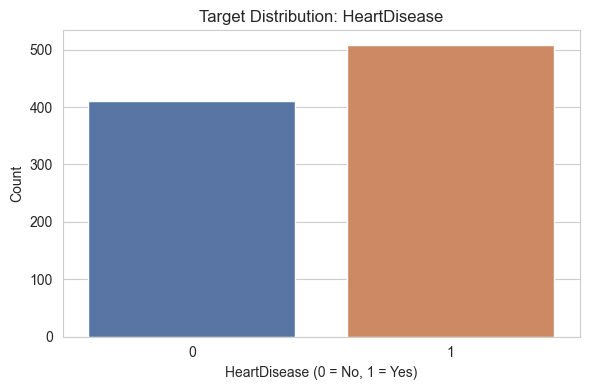

In [22]:
#Univariate Analysis — Target 
import matplotlib.pyplot as plt
import seaborn as sns

def plot_target_distribution(df, target_col):
    plt.figure(figsize=(6, 4))
    
    sns.countplot(
        data=df,
        x=target_col,
        hue=target_col,      # required for palette (v0.14+)
        palette={
            0: "#4C72B0",     # No Heart Disease
            1: "#DD8452"      # Heart Disease
        },
        legend=False
    )
    
    plt.title(f"Target Distribution: {target_col}")
    plt.xlabel(f"{target_col} (0 = No, 1 = Yes)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

TARGET = "HeartDisease"
plot_target_distribution(df, TARGET)

--- Numerical Features Distribution ---


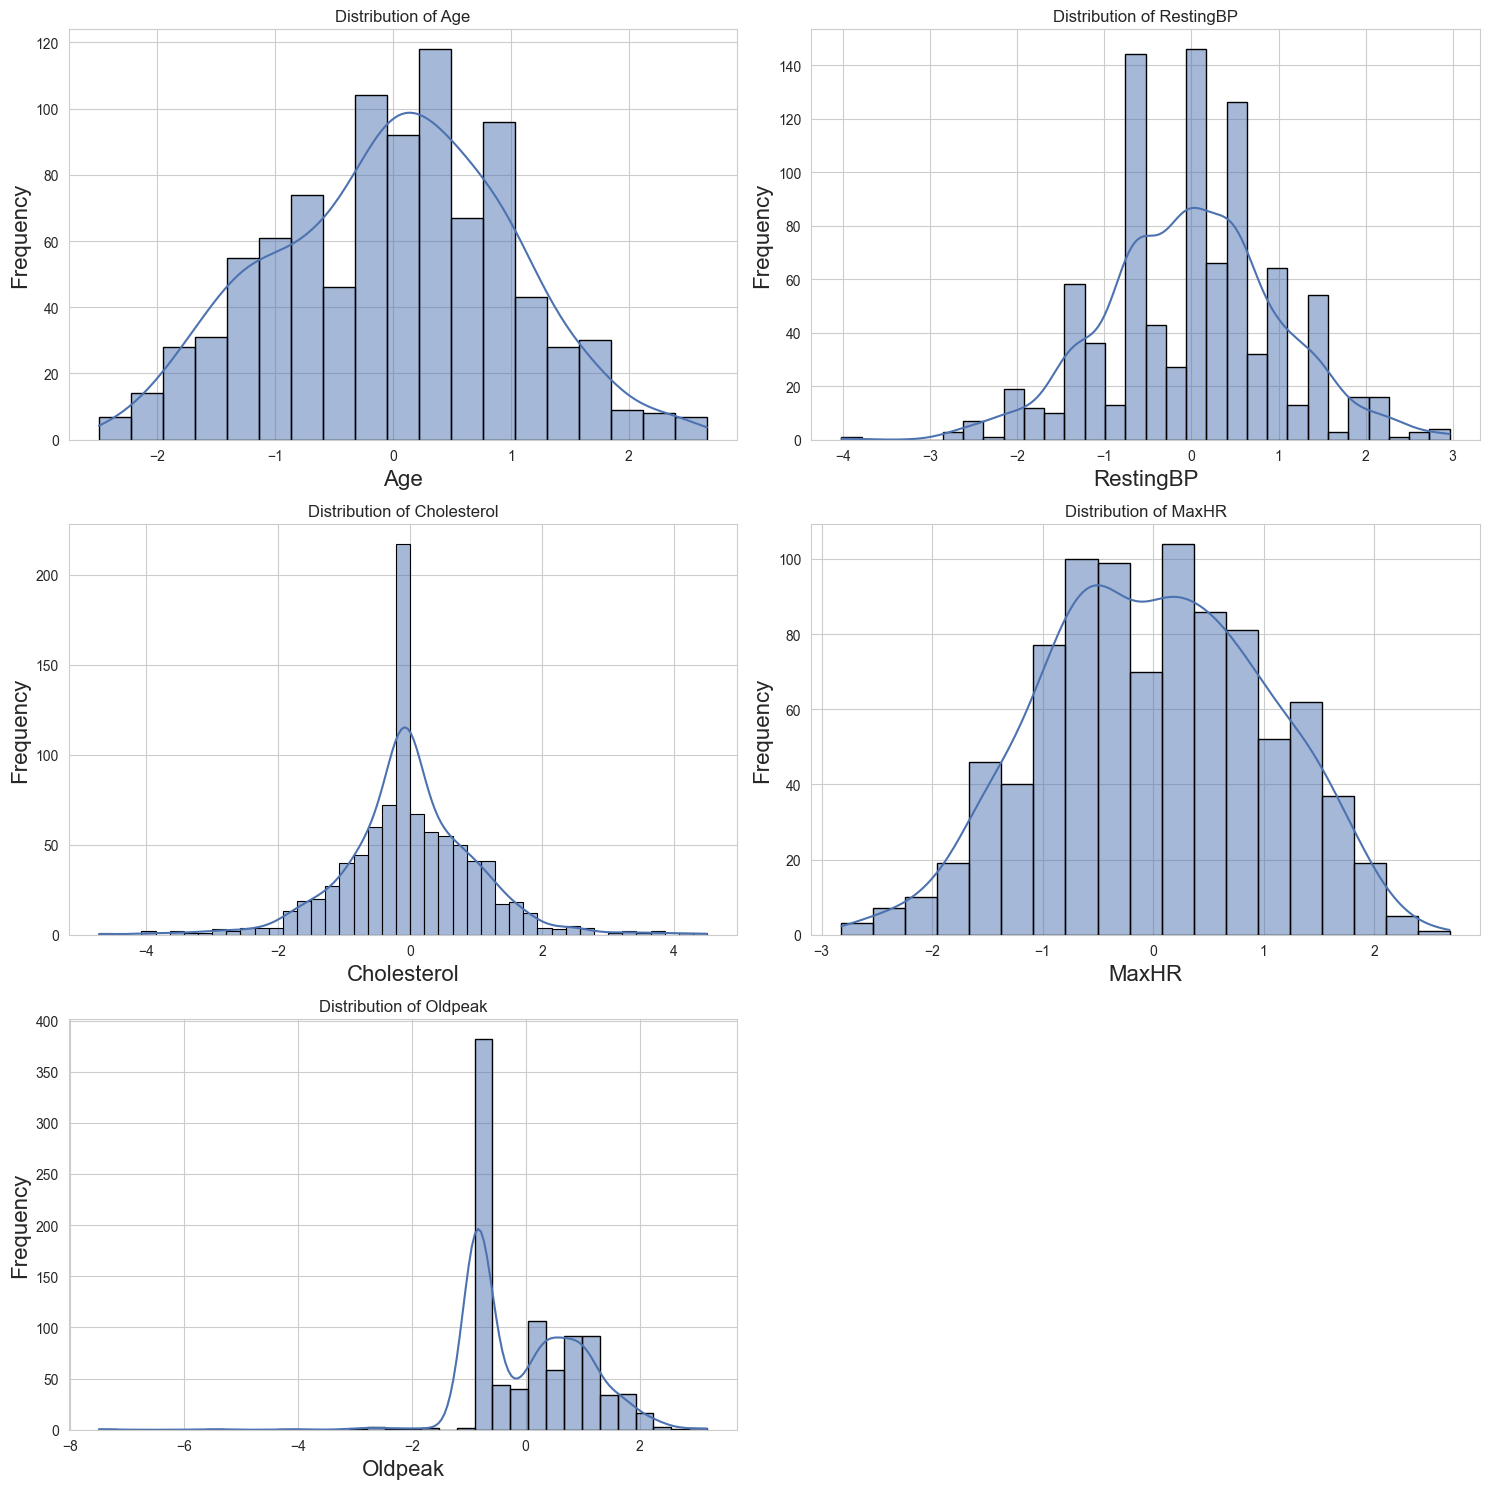


--- Categorical Features Distribution ---


/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/3208173134.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/3208173134.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/3208173134.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='bla

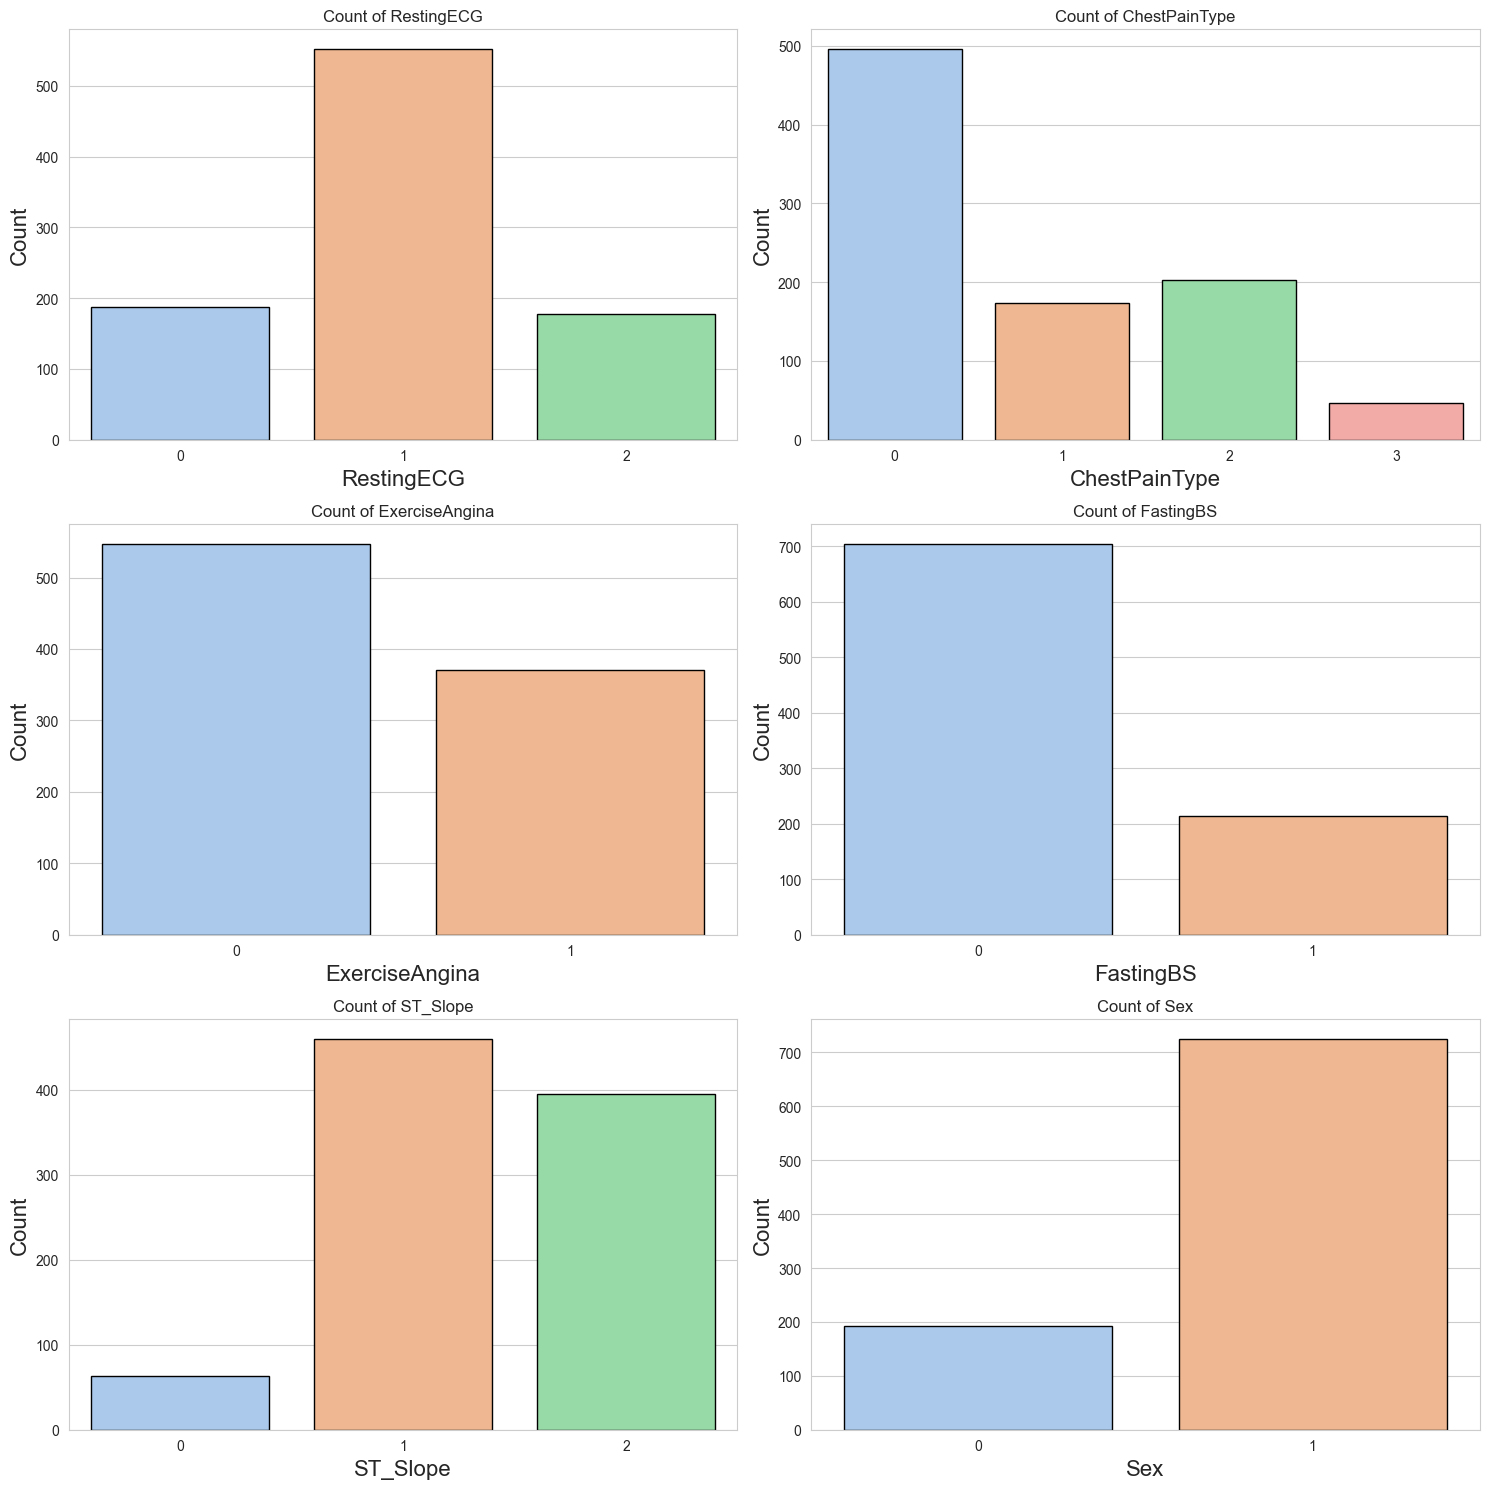

<Figure size 640x480 with 0 Axes>

In [ ]:
#Univariate Analysis
import math

def plot_numerical(df, features):
    n_cols = 2
    n_rows = math.ceil(len(features) / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, color='#4C72B0', edgecolor='black')
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel(col, fontsize=16)
        plt.ylabel('Frequency', fontsize=16)
        plt.savefig("num.png", dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

def plot_categorical(df, features):
    n_cols = 2
    n_rows = math.ceil(len(features) / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
        plt.title(f'Count of {col}', fontsize=12)
        plt.xlabel(col, fontsize=16)
        plt.ylabel('Count', fontsize=16)

    plt.tight_layout()
    plt.show()
    plt.savefig("cat.png", dpi=300, bbox_inches='tight')

print("--- Numerical Features Distribution ---")
plot_numerical(df, numerical_cols)

print("\n--- Categorical Features Distribution ---")
plot_categorical(df, categorical_cols)


/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/658247014.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/658247014.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/658247014.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/658247014.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

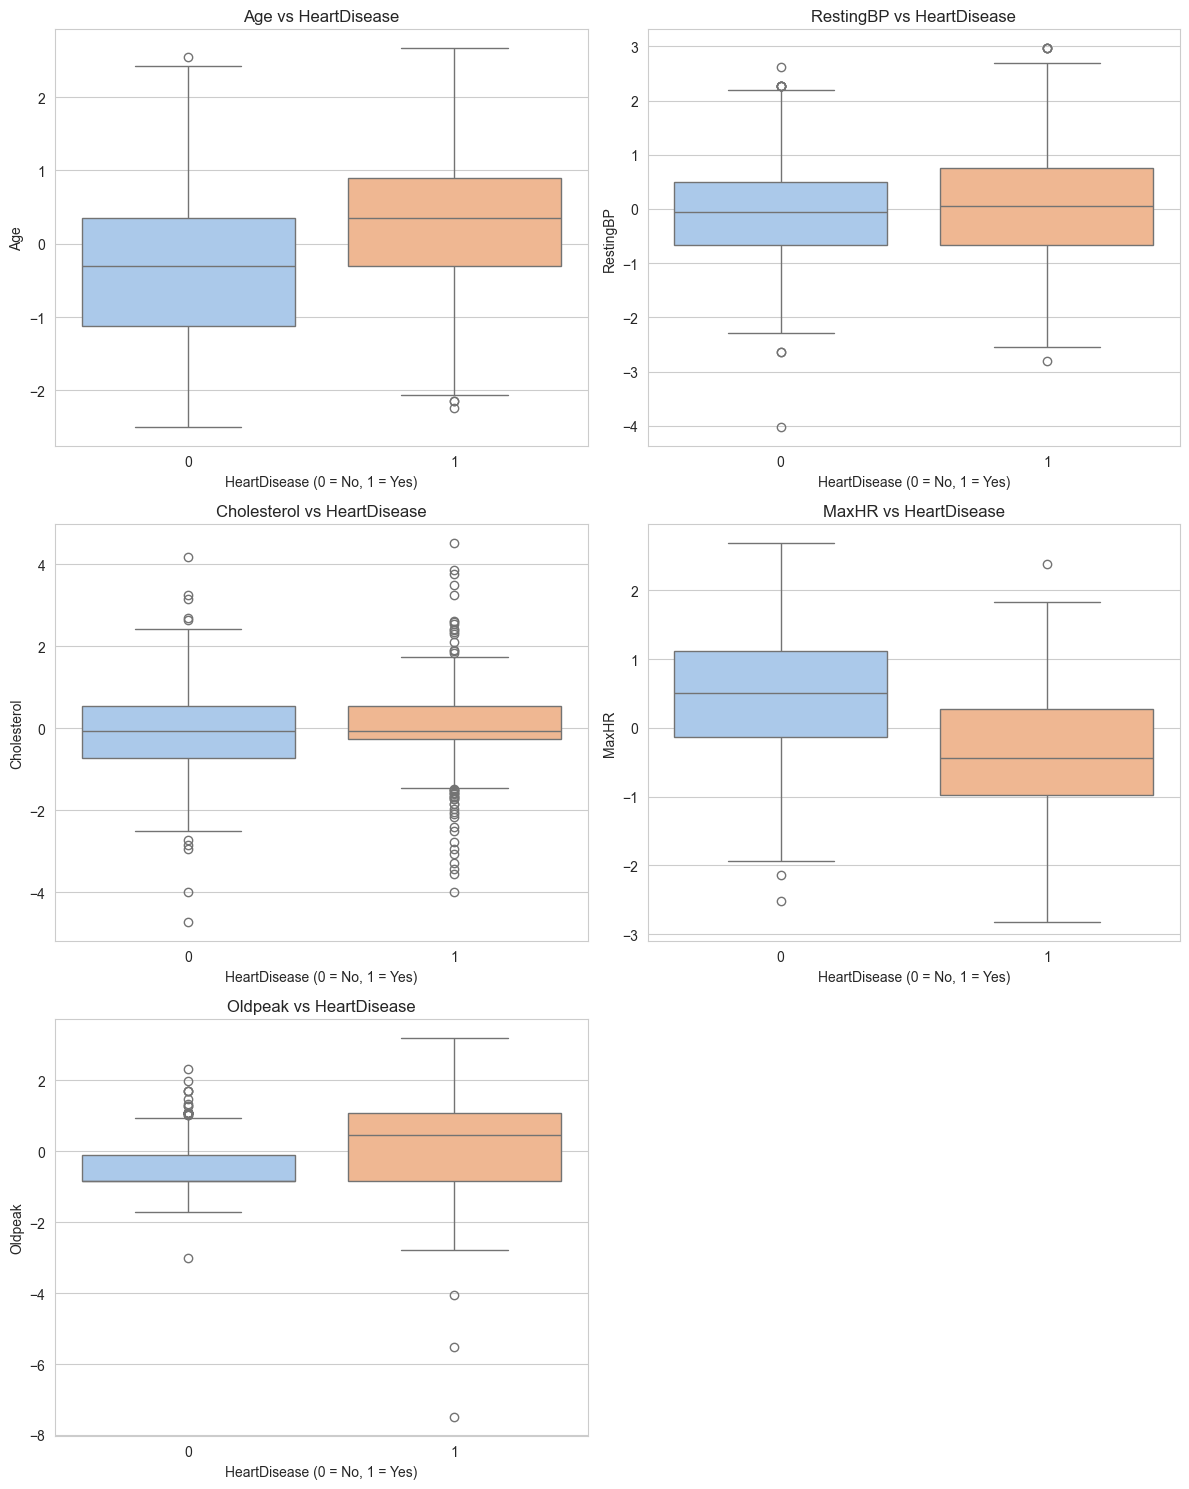

In [ ]:
#Bivariate Analysis: Numerical × Target


def plot_numerical_vs_target(df, numerical_cols, target):
    
    n_cols = 2
    n_rows = math.ceil(len(numerical_cols) / n_cols)

    plt.figure(figsize=(12, 5 * n_rows))

    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        
        sns.boxplot(
            x=df[target],
            y=df[col],
            palette='pastel',
            showfliers=True
      
        )
        
        plt.title(f"{col} vs {target}", fontsize=12)
        plt.xlabel("HeartDisease (0 = No, 1 = Yes)", fontsize=10)
        plt.ylabel(col, fontsize=10)

    plt.tight_layout()
    
    plt.savefig("num_vs_target.png", dpi=300, bbox_inches='tight')
    
    plt.show()

plot_numerical_vs_target(df, numerical_cols, TARGET)

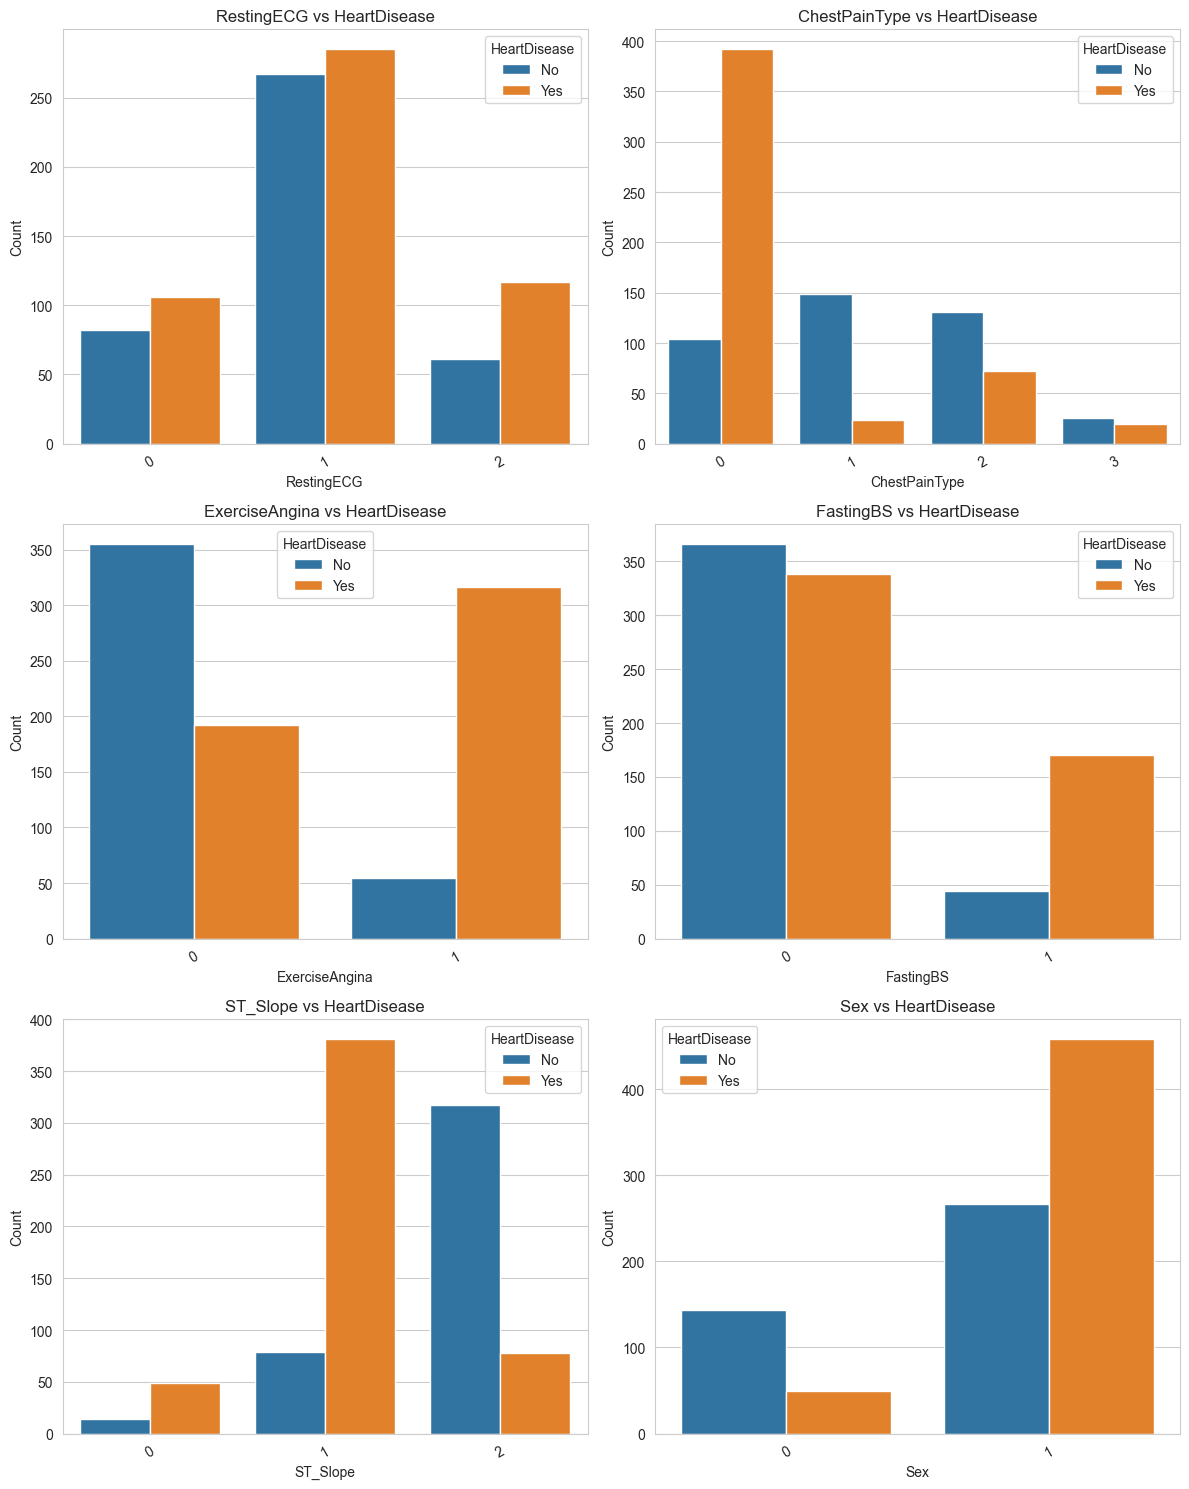

In [ ]:
#Bivariate Analysis: Categorical × Target


def plot_categorical_vs_target(df, categorical_cols, target):
    
    n_cols = 2
    n_rows = math.ceil(len(categorical_cols) / n_cols)

    plt.figure(figsize=(12, 5 * n_rows))

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        
        sns.countplot(
            data=df,
            x=col,
            hue=target
        )
        
        plt.title(f"{col} vs {target}", fontsize=12)
        plt.xlabel(col, fontsize=10)
        plt.ylabel("Count", fontsize=10)
        plt.xticks(rotation=30)

        # Consistent legend
        plt.legend(title="HeartDisease", labels=["No", "Yes"])

    plt.tight_layout()
    plt.savefig("cat_vs_target.png", dpi=300, bbox_inches='tight')

    plt.show()

plot_categorical_vs_target(df, categorical_cols, TARGET)

/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/2035105254.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/2035105254.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/2035105254.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/2035105254.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

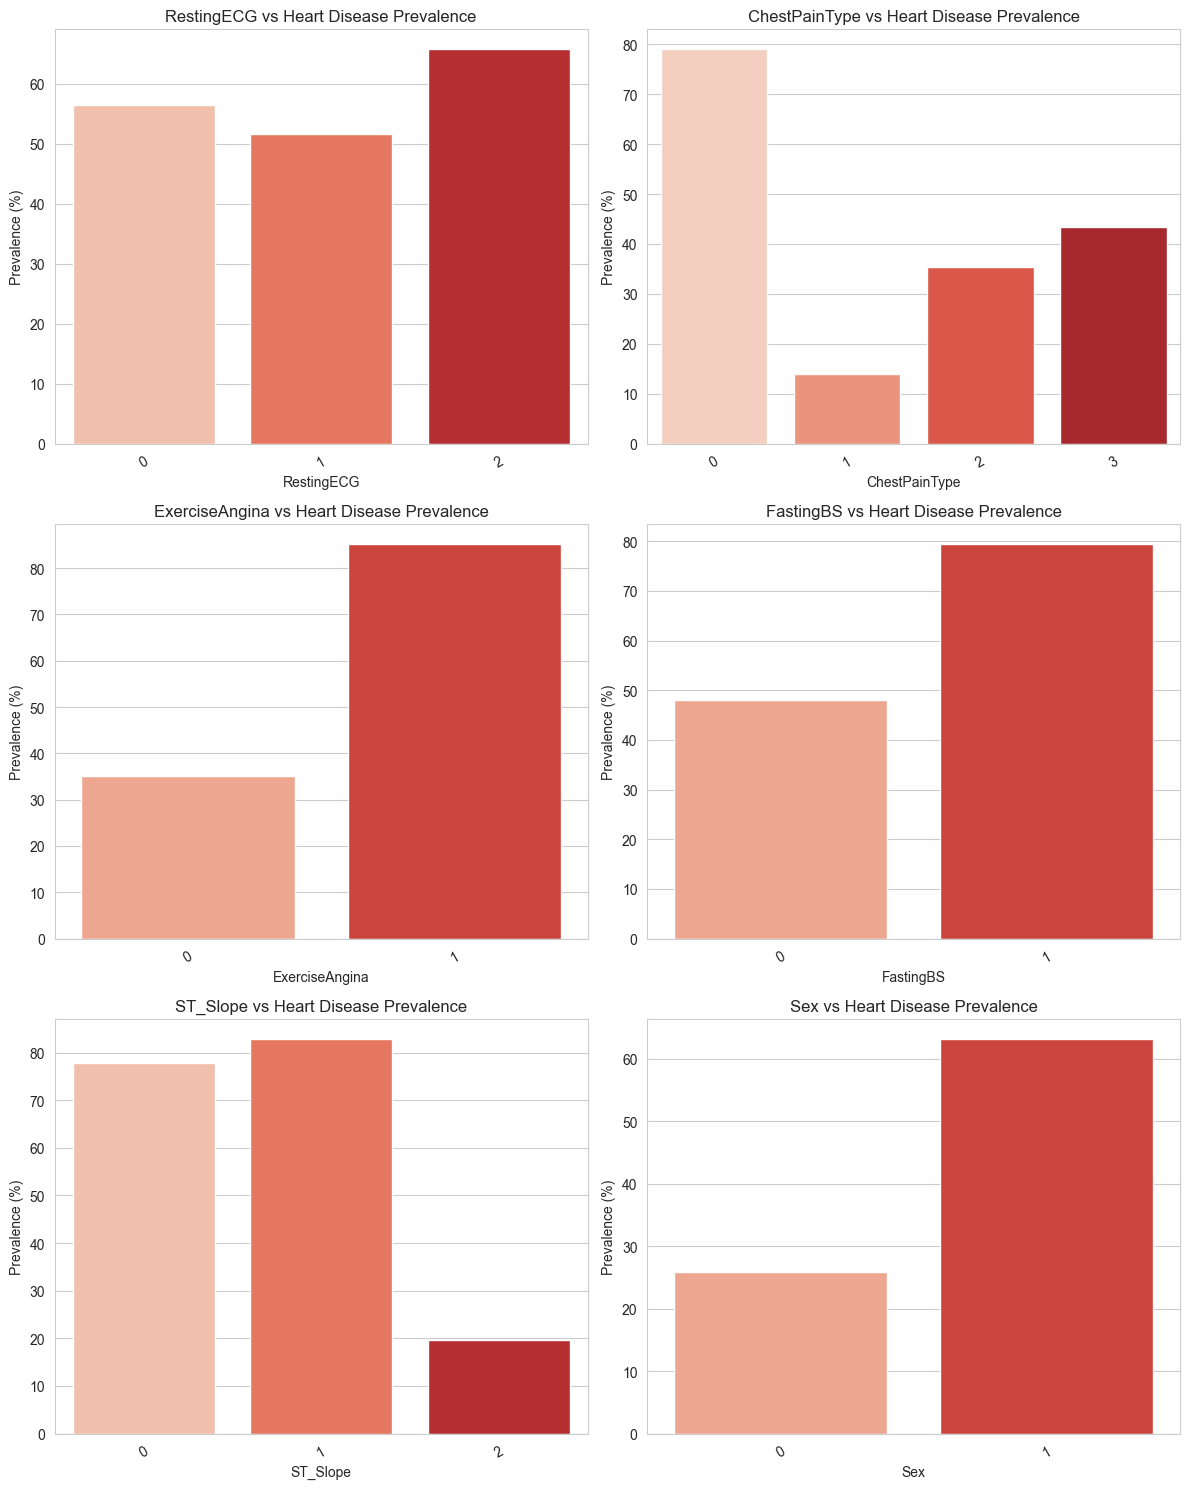

In [ ]:
#Group Disparity
def plot_all_categorical_disparity(df, categorical_cols, target_col):
    
    n_cols = 2
    n_rows = math.ceil(len(categorical_cols) / n_cols)

    plt.figure(figsize=(12, 5 * n_rows))

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        prevalence = (
            df.groupby(col)[target_col]
            .mean()
            .reset_index()
        )
        prevalence[target_col] = prevalence[target_col] * 100

        sns.barplot(
            data=prevalence,
            x=col,
            y=target_col,
            palette="Reds"
        )

        plt.title(f"{col} vs Heart Disease Prevalence", fontsize=12)
        plt.xlabel(col, fontsize=10)
        plt.ylabel("Prevalence (%)", fontsize=10)
        plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig("categorical_disparity.png", dpi=300, bbox_inches='tight')

    plt.show()
plot_all_categorical_disparity(df, categorical_cols, TARGET)

In [ ]:
X_num = df[numerical_cols]
y = df[TARGET]

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(
    X_num,
    y,
    discrete_features=False,
    random_state=42
)

mi_series = pd.Series(
    mi_scores,
    index=numerical_cols,
    name="Mutual Information"
).sort_values(ascending=False)

print("Mutual Information Scores (Numerical Features)")
mi_series





Mutual Information Scores (Numerical Features)


Oldpeak        0.096169
MaxHR          0.080392
Cholesterol    0.063261
Age            0.057453
RestingBP      0.032280
Name: Mutual Information, dtype: float64

/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/2923641548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


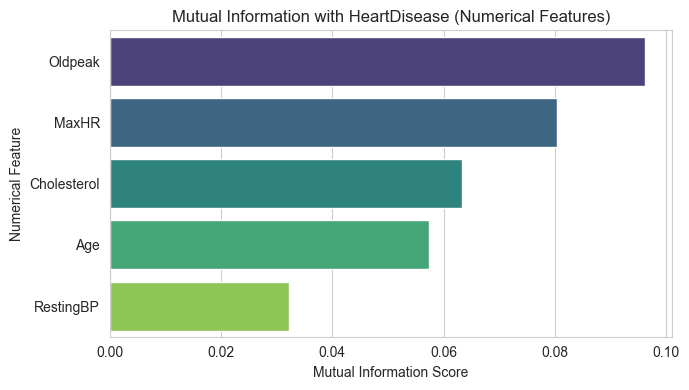

In [ ]:
#Mutual Information Analysis for Numerical Features

plt.figure(figsize=(7, 4))

sns.barplot(
    x=mi_series.values,
    y=mi_series.index,
    palette="viridis"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Numerical Feature")
plt.title("Mutual Information with HeartDisease (Numerical Features)")
plt.tight_layout()
plt.savefig("mia1.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Cramer's V for categorical Features
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
cramers_results = {}

for col in categorical_cols:
    cramers_results[col] = round(
        cramers_v(df[col], df[TARGET]),
        3
    )

cramers_v_series = pd.Series(
    cramers_results,
    name="Cramer's V"
).sort_values(ascending=False)

print("Cramér's V Scores")
cramers_v_series


Cramér's V Scores


ST_Slope          0.621
ChestPainType     0.538
ExerciseAngina    0.491
Sex               0.301
FastingBS         0.263
RestingECG        0.099
Name: Cramer's V, dtype: float64

/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_64987/546506415.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


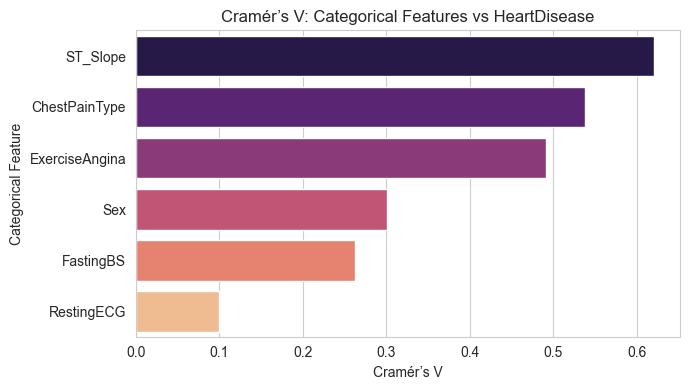

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))

sns.barplot(
    x=cramers_v_series.values,
    y=cramers_v_series.index,
    palette="magma"
)

plt.xlabel("Cramér’s V")
plt.ylabel("Categorical Feature")
plt.title("Cramér’s V: Categorical Features vs HeartDisease")
plt.tight_layout()
plt.savefig("cramers1.png", dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance

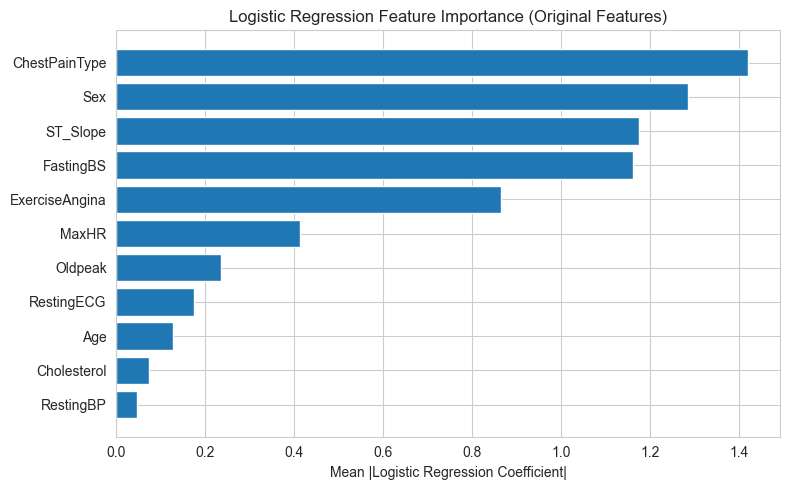

In [ ]:
#Feature importace - Logostic Regrssion
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocess_robust = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

lr_pipeline = Pipeline([
    ("preprocess", preprocess_robust),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

preprocessor = lr_pipeline.named_steps["preprocess"]
lr_model = lr_pipeline.named_steps["classifier"]

numerical_cols = [
    "Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"
]

categorical_cols = [
    "Sex", "FastingBS", "ExerciseAngina",
    "ChestPainType", "RestingECG", "ST_Slope"
]

num_features = numerical_cols

cat_features = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out()
    .tolist()
)

processed_feature_names = num_features + cat_features

feature_map = {}

# Numerical features
for col in numerical_cols:
    feature_map[col] = col

# Categorical (safe prefix match)
for fname in cat_features:
    for parent in categorical_cols:
        if fname.startswith(parent + "_"):
            feature_map[fname] = parent
            break

coef = lr_model.coef_.flatten()

coef_df = pd.DataFrame({
    "ProcessedFeature": processed_feature_names,
    "Coefficient": coef
})

coef_df["OriginalFeature"] = coef_df["ProcessedFeature"].map(feature_map)

# Aggregate to original features using mean absolute coefficient
importance_df = (
    coef_df
    .groupby("OriginalFeature")["Coefficient"]
    .apply(lambda x: np.mean(np.abs(x)))
    .reset_index()
    .rename(columns={"Coefficient": "Mean_Abs_Coefficient"})
    .sort_values("Mean_Abs_Coefficient", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["OriginalFeature"],
    importance_df["Mean_Abs_Coefficient"]
)

plt.xlabel("Mean |Logistic Regression Coefficient|")
plt.title("Logistic Regression Feature Importance (Original Features)")
plt.tight_layout()
plt.show()


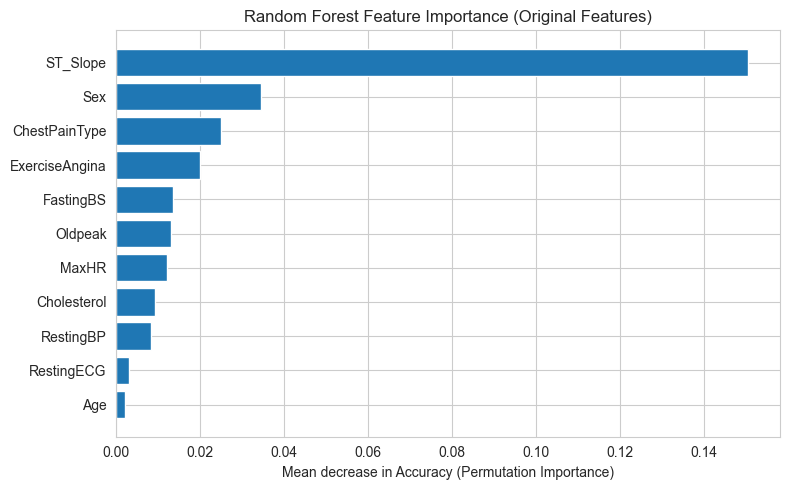

In [ ]:
#feature importace - Random Forest

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

numerical_cols = [
    "Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"
]

categorical_cols = [
    "Sex", "FastingBS", "ExerciseAngina",
    "ChestPainType", "RestingECG", "ST_Slope"
]

preprocess = ColumnTransformer([
    ("num", RobustScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

perm_result_rf = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)


importance_df_rf = pd.DataFrame({
    "Feature": X_test.columns,   # original features (pipeline handles encoding)
    "Importance": perm_result_rf.importances_mean
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df_rf["Feature"],
    importance_df_rf["Importance"]
)

plt.xlabel("Mean decrease in Accuracy (Permutation Importance)")
plt.title("Random Forest Feature Importance (Original Features)")
plt.tight_layout()
plt.show()

### Exponentiated Gradient - Demographic Parity

In [ ]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}


def gender_metrics_dp(model, X_test, y_test, gender_col="Sex"):
    
    results = {}

    for val, label in [(0, "Female"), (1, "Male")]:
        idx = X_test[gender_col] == val

        X_g = X_test.loc[idx]
        y_g = y_test.loc[idx]

        y_pred = model.predict(X_g)

        results[label] = {
            "Accuracy": accuracy_score(y_g, y_pred),
            "Recall": recall_score(y_g, y_pred),
            "Positive Rate": np.mean(y_pred)  # for DP
        }

    # Equal Opportunity Gap
    eo_gap = abs(results["Female"]["Recall"] - results["Male"]["Recall"])

    # Demographic Parity Gap
    dp_gap = abs(results["Female"]["Positive Rate"] - results["Male"]["Positive Rate"])

    return results, eo_gap, dp_gap

rows = []

# Protected attribute
A_train = X_train["Sex"]
A_test = X_test["Sex"]

for name, base_model in models.items():

    # -------- BASELINE --------
    base_model.fit(X_train, y_train)
    base_res, base_eo, base_dp = gender_metrics_dp(base_model, X_test, y_test)

    # -------- FAIRLEARN MODEL --------
    mitigator = ExponentiatedGradient(
        estimator=base_model,
        constraints=DemographicParity()
    )

    mitigator.fit(X_train, y_train, sensitive_features=A_train)

    fair_res, fair_eo, fair_dp = gender_metrics_dp(mitigator, X_test, y_test)

    # -------- STORE RESULTS --------
    rows.append({
        "Model": name,
        "Type": "Baseline",
        "Female Recall": base_res["Female"]["Recall"],
        "Male Recall": base_res["Male"]["Recall"],
        "EO Gap": base_eo,
        "DP Gap": base_dp
    })

    rows.append({
        "Model": name,
        "Type": "Fairlearn (DP)",
        "Female Recall": fair_res["Female"]["Recall"],
        "Male Recall": fair_res["Male"]["Recall"],
        "EO Gap": fair_eo,
        "DP Gap": fair_dp
    })


final_results = pd.DataFrame(rows)
final_results

,Model,Type,Female Recall,Male Recall,EO Gap,DP Gap
0,Logistic Regression,Baseline,0.666667,0.875000,0.208333,0.480173
1,Logistic Regression,Fairlearn (DP),1.000000,0.833333,0.166667,0.135905
2,Random Forest,Baseline,0.833333,0.895833,0.062500,0.506489
3,Random Forest,Fairlearn (DP),0.833333,0.906250,0.072917,0.355443


### Exponentiated gradient - Equalized Odds

In [ ]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import pandas as pd
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}


def gender_metrics_eo(model, X_test, y_test, gender_col="Sex"):
    
    results = {}

    for val, label in [(0, "Female"), (1, "Male")]:
        idx = X_test[gender_col] == val

        X_g = X_test.loc[idx]
        y_g = y_test.loc[idx]

        y_pred = model.predict(X_g)

        tn, fp, fn, tp = confusion_matrix(y_g, y_pred).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        results[label] = {
            "Recall (TPR)": tpr,
            "FPR": fpr
        }

    # Equalized Odds gaps
    tpr_gap = abs(results["Female"]["Recall (TPR)"] - results["Male"]["Recall (TPR)"])
    fpr_gap = abs(results["Female"]["FPR"] - results["Male"]["FPR"])

    return results, tpr_gap, fpr_gap

rows = []

A_train = X_train["Sex"]

for name, base_model in models.items():

    base_model.fit(X_train, y_train)
    base_res, base_tpr_gap, base_fpr_gap = gender_metrics_eo(base_model, X_test, y_test)

    mitigator = ExponentiatedGradient(
        estimator=base_model,
        constraints=EqualizedOdds()
    )

    mitigator.fit(X_train, y_train, sensitive_features=A_train)

    fair_res, fair_tpr_gap, fair_fpr_gap = gender_metrics_eo(mitigator, X_test, y_test)

    rows.append({
        "Model": name,
        "Type": "Baseline",
        "Female Recall": base_res["Female"]["Recall (TPR)"],
        "Male Recall": base_res["Male"]["Recall (TPR)"],
        "TPR Gap": base_tpr_gap,
        "FPR Gap": base_fpr_gap
    })

    rows.append({
        "Model": name,
        "Type": "Fairlearn (EO)",
        "Female Recall": fair_res["Female"]["Recall (TPR)"],
        "Male Recall": fair_res["Male"]["Recall (TPR)"],
        "TPR Gap": fair_tpr_gap,
        "FPR Gap": fair_fpr_gap
    })


final_results = pd.DataFrame(rows)
final_results

,Model,Type,Female Recall,Male Recall,TPR Gap,FPR Gap
0,Logistic Regression,Baseline,0.666667,0.875000,0.208333,0.16625
1,Logistic Regression,Fairlearn (EO),0.833333,0.875000,0.041667,0.08375
2,Random Forest,Baseline,0.833333,0.895833,0.062500,0.18875
3,Random Forest,Fairlearn (EO),0.833333,0.906250,0.072917,0.18875


### AIF360 style Reweighting

In [ ]:
#AIF360 style reweighting for selected features.
import numpy as np
import pandas as pd

X_train_rw = X_train.copy()

# Protected features
X_train_rw['prot_FastingBS'] = X_train_rw['FastingBS']
X_train_rw['prot_MaxHR'] = (X_train_rw['MaxHR'] < X_train_rw['MaxHR'].median()).astype(int)
#X_train_rw['prot_MaxHR'] = (X_train_rw['MaxHR'] < 120).astype(int)
X_train_rw['prot_RestingBP'] = (X_train_rw['RestingBP'] >= 130).astype(int)
X_train_rw['prot_Cholesterol'] = (X_train_rw['Cholesterol'] >= 240).astype(int)

if 'RestingECG_ST' in X_train_rw.columns:
    X_train_rw['prot_RestingECG'] = X_train_rw['RestingECG_ST']
else:
    X_train_rw['prot_RestingECG'] = (X_train_rw['RestingECG'] != 0).astype(int)

protected_features = [
    'prot_FastingBS',
    'prot_MaxHR',
    'prot_RestingBP',
    'prot_Cholesterol',
    'prot_RestingECG'
]

def compute_reweighting(df, label_col, protected_col):
    weights = np.zeros(len(df))
    for a in [0,1]:
        for y in [0,1]:
            mask = (df[protected_col] == a) & (df[label_col] == y)
            P_a = (df[protected_col] == a).mean()
            P_y = (df[label_col] == y).mean()
            P_ay = mask.mean()
            if P_ay > 0:
                weights[mask] = (P_a * P_y) / P_ay
    return weights

train_df_full = X_train_rw.copy()
train_df_full['HeartDisease'] = y_train

combined_weights = np.ones(len(train_df_full))
for prot in protected_features:
    combined_weights *= compute_reweighting(train_df_full, 'HeartDisease', prot)

#print("Reweighting completed.")


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

def gender_metrics_with_gap(model, X_test, y_test, gender_col="Sex"):
    
    results = {}

    for gender_value, gender_label in [(0, "Female"), (1, "Male")]:
        idx = X_test[gender_col] == gender_value

        X_g = X_test.loc[idx]
        y_g = y_test.loc[idx]

        y_pred = model.predict(X_g)

        results[gender_label] = {
            "Accuracy": accuracy_score(y_g, y_pred),
            "Recall": recall_score(y_g, y_pred)
        }

    # Equal Opportunity Gap = |Recall_female - Recall_male|
    gap = abs(results["Female"]["Recall"] - results["Male"]["Recall"])

    return results, gap


final_rows = []

for model_name, model in models.items():
    
    model.fit(X_train, y_train)
    base_results, base_gap = gender_metrics_with_gap(model, X_test, y_test)

    model.fit(X_train, y_train, sample_weight=combined_weights)
    rw_results, rw_gap = gender_metrics_with_gap(model, X_test, y_test)

    final_rows.append({
        "Model": model_name,
        "Type": "Baseline",
        "Female Recall": base_results["Female"]["Recall"],
        "Male Recall": base_results["Male"]["Recall"],
        "Equal Opportunity Gap": base_gap
    })

    final_rows.append({
        "Model": model_name,
        "Type": "Reweighted",
        "Female Recall": rw_results["Female"]["Recall"],
        "Male Recall": rw_results["Male"]["Recall"],
        "Equal Opportunity Gap": rw_gap
    })


final_results = pd.DataFrame(final_rows)
final_results

Reweighting completed.


,Model,Type,Female Recall,Male Recall,Equal Opportunity Gap
0,Logistic Regression,Baseline,0.666667,0.916667,0.250000
1,Logistic Regression,Reweighted,0.666667,0.833333,0.166667
2,Random Forest,Baseline,0.500000,0.875000,0.375000
3,Random Forest,Reweighted,0.500000,0.864583,0.364583
